In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
#Dropping unnecessary columns
df.drop("CustomerID",axis=1,inplace=True)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [7]:

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [9]:
# Select features for clustering (Annual Income & Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [11]:
# 3️Standardize the data for better distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_scaled = pd.DataFrame(X_scaled)
X_scaled

,0,1
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


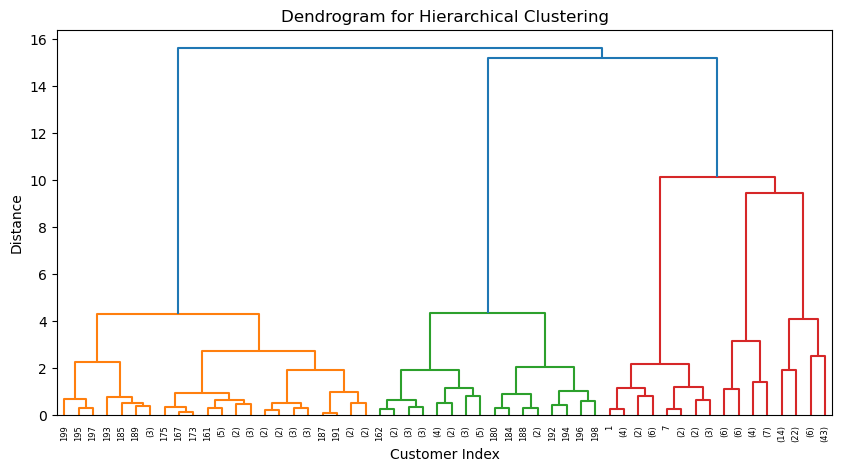

In [19]:
# Compute the distance matrix and plot the dendrogram
linked = linkage(X_scaled, method='ward')  # Ward’s method minimizes variance

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()

In [39]:
#  Choose the number of clusters based on dendrogram and apply clustering
num_clusters = 5  # Adjust based on dendrogram cutoff
hc = AgglomerativeClustering(n_clusters=num_clusters, metric='euclidean', linkage='ward')
df['Cluster'] = hc.fit_predict(X_scaled)

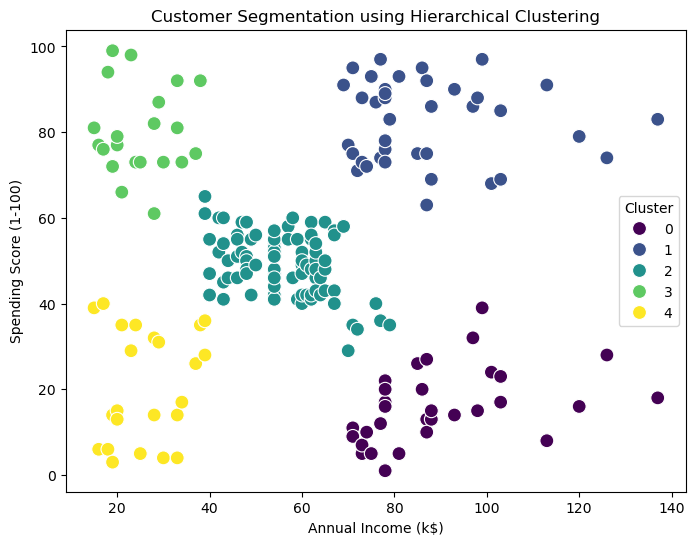

In [41]:
# Visualizing Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=df['Cluster'], palette='viridis', s=100)
plt.title("Customer Segmentation using Hierarchical Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

In [43]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])

print(f"Silhouette Score for {num_clusters} clusters: {silhouette_avg:.4f}")

Silhouette Score for 5 clusters: 0.5538
